In [15]:
import pandas as pd

# Data Normalize (Xoá khoảng trắng)

In [16]:
def normalize_products(df):
    print("\nNORMALIZING CATEGORICAL COLUMNS...")

    cat_cols = ["product_name", "category", "segment", "size", "color"]

    for col in cat_cols:
        df[col] = df[col].astype(str).str.strip()

    print("Done trimming whitespace")

    # Check unique values
    for col in ["category", "segment", "size", "color"]:
        print(f"\n--{col.upper()} WITH {df[col].nunique()} UNIQUE VALUES INCLUDE: {df[col].unique().tolist()}")

    return df

# CrossTab plot giữa category và segment

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def plot_category_segment(df):
    print("\nCATEGORY vs SEGMENT DISTRIBUTION")

    cross_tab = pd.crosstab(df['category'], df['segment'])

    print("\nCross-tab summary:")
    print(cross_tab)

    sns.stripplot(data=df, x='category', y='segment', hue='category', palette='viridis')
    plt.title("Category vs Segment Scatter")
    plt.xlabel("Segment")
    plt.ylabel("Category")
    plt.show()


# Relation Analysis between Price and COGS

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

def explore_continuous_relationship(df, col_x, col_y, bins=30, alpha=0.5):
    """
    Phân tích toàn diện mối quan hệ giữa hai biến liên tục.
    
    Parameters:
    df : pandas.DataFrame
    col_x, col_y : str
    bins : int, số lượng bins cho histogram
    alpha : float, độ mờ cho scatter plot
    """
    # 1. In thống kê tóm tắt và kiểm định tương quan
    print("\n" + "="*60)
    print(f"PHÂN TÍCH MỐI QUAN HỆ GIỮA '{col_x}' VÀ '{col_y}'")
    print("="*60)
    
    # Loại bỏ missing values
    data = df[[col_x, col_y]].dropna()
    x = data[col_x]
    y = data[col_y]

    x_log = np.log1p(x)
    y_log = np.log1p(y)
    
    # Thống kê cơ bản
    print(f"\n[1] THỐNG KÊ MÔ TẢ:")
    print(f"   - {col_x}: mean = {x.mean():.2f}, std = {x.std():.2f}, min = {x.min():.2f}, max = {x.max():.2f}")
    print(f"   - {col_y}: mean = {y.mean():.2f}, std = {y.std():.2f}, min = {y.min():.2f}, max = {y.max():.2f}")
    print(f"   - Chênh lệch trung bình ({col_x} - {col_y}): {(x - y).mean():.2f}")
    
    # Hệ số tương quan
    pearson_r, pearson_p = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)
    print(f"\n[2] TƯƠNG QUAN:")
    print(f"   - Pearson: r = {pearson_r:.3f} (p-value = {pearson_p:.2e}) → {'có' if pearson_p < 0.05 else 'không'} ý nghĩa thống kê")
    print(f"   - Spearman: ρ = {spearman_r:.3f} (p-value = {spearman_p:.2e}) → {'có' if spearman_p < 0.05 else 'không'} ý nghĩa thống kê")
    
    # 2. Vẽ các biểu đồ chính
    # Figure 1: Joint Distribution + Regression + Residuals
    fig = plt.figure(figsize=(14, 10))
    
    # --- Scatter plot với marginal histograms (jointplot style) ---
    ax_main = plt.subplot2grid((3, 3), (0, 0), colspan=2, rowspan=2)
    ax_main.scatter(x_log, y_log, alpha=alpha, s=20, c='steelblue', edgecolors='white', linewidth=0.5)
    ax_main.set_xlabel(col_x, fontsize=11)
    ax_main.set_ylabel(col_y, fontsize=11)
    ax_main.set_title(f"Biểu đồ phân tán và đường hồi quy", fontsize=13)
    
    # Vẽ đường hồi quy tuyến tính
    model = LinearRegression().fit(x.values.reshape(-1,1), y)
    x_range = np.linspace(x.min(), x.max(), 100)
    y_pred_global = model.predict(x_range.reshape(-1,1))
    ax_main.plot(x_range, y_pred_global, 'r-', linewidth=2, label=f'Linear fit (y={model.coef_[0]:.2f}x + {model.intercept_:.2f})')
    
    # Vẽ đường LOWESS (phi tuyến)
    from statsmodels.nonparametric.smoothers_lowess import lowess
    lowess_smoothed = lowess(y, x, frac=0.3)
    ax_main.plot(lowess_smoothed[:,0], lowess_smoothed[:,1], 'g--', linewidth=2, label='Lowess smoother')
    ax_main.legend(loc='best')
    
    # Marginal histograms
    ax_hist_x = plt.subplot2grid((3, 3), (0, 2))
    sns.histplot(x_log, bins=bins, color='steelblue', alpha=0.7, edgecolor='black', kde=True, ax=ax_hist_x, fill=True)
    ax_hist_x.lines[0].set_color('red')
    ax_hist_x.set_title(f'Phân phối {col_x} (log transform)')
    ax_hist_x.set_xlabel(col_x)
    
    ax_hist_y = plt.subplot2grid((3, 3), (1, 2))
    sns.histplot(y_log, bins=bins, color='steelblue', alpha=0.7, edgecolor='black', kde=True, ax=ax_hist_y, fill=True)
    ax_hist_y.lines[0].set_color('red')
    ax_hist_y.set_title(f'Phân phối {col_y} (log transform)')
    ax_hist_y.set_ylabel(col_y)
    
    # --- Residual plot ---
    residuals = y - model.predict(x.values.reshape(-1,1))
    ax_res = plt.subplot2grid((3, 3), (2, 0), colspan=2)
    ax_res.scatter(model.predict(x.values.reshape(-1,1)), residuals, alpha=alpha, c='darkred', s=20)
    ax_res.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax_res.set_xlabel(f"Giá trị dự đoán của {col_y}")
    ax_res.set_ylabel("Phần dư")
    ax_res.set_title("Biểu đồ phần dư – kiểm tra tính tuyến tính và phương sai đồng nhất")
    
    # Thêm caption cho toàn figure
    fig.suptitle(f"Phân tích toàn diện quan hệ giữa '{col_x}' và '{col_y}'", fontsize=14, fontweight='bold')
    caption = (f"Caption: Scatter plot thể hiện xu hướng chung. Đường đỏ: hồi quy tuyến tính; "
               f"đường xanh đứt: Lowess (phát hiện phi tuyến). Residual plot kiểm tra giả định: "
               f"nếu phần dư phân tán ngẫu nhiên quanh 0 → mô hình tuyến tính phù hợp.")
    fig.text(0.5, 0.01, caption, ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()
    
    # 3. Kiểm tra giả định phương sai đồng nhất (Breusch-Pagan)
    X = sm.add_constant(x)
    model_sm = sm.OLS(y, X).fit()
    bp_test = het_breuschpagan(model_sm.resid, X)
    print(f"\n[3] KIỂM TRA PHƯƠNG SAI THAY ĐỔI (Breusch-Pagan):")
    print(f"   - LM statistic = {bp_test[0]:.3f}, p-value = {bp_test[1]:.2e}")
    print(f"   - Kết luận: {'Có dấu hiệu phương sai thay đổi (homoscedasticity bị vi phạm)' if bp_test[1] < 0.05 else 'Phương sai đồng nhất (homoscedasticity)'}")
    
    # 4. Figure 2: Biểu đồ mật độ 2D (hexbin hoặc kde) – hữu ích khi dữ liệu lớn
    fig2, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Hexbin
    hb = axes[0].hexbin(x, y, gridsize=40, cmap='Blues', edgecolors='none', mincnt=1)
    axes[0].set_xlabel(col_x)
    axes[0].set_ylabel(col_y)
    axes[0].set_title(f"Hexbin – tần số điểm (màu càng đậm càng nhiều điểm)")
    fig2.colorbar(hb, ax=axes[0], label='Số lượng điểm trong ô')
    
    # KDE 2D
    sns.kdeplot(x=x, y=y, ax=axes[1], cmap='Reds', fill=True, thresh=0.05, levels=20)
    axes[1].set_xlabel(col_x)
    axes[1].set_ylabel(col_y)
    axes[1].set_title(f"KDE 2D – mật độ xác suất")
    
    fig2.suptitle(f"Biểu đồ mật độ cho '{col_x}' và '{col_y}' (dùng khi dữ liệu lớn / chồng lấn nhiều)", fontsize=12)
    fig2.tight_layout()
    plt.show()
    
    # 5. Binning theo phân vị (để thấy xu hướng trung bình vững hơn)
    try:
        data['x_bin'] = pd.qcut(x, q=10, duplicates='drop')
        bin_means = data.groupby('x_bin')[col_y].mean()
        bin_counts = data.groupby('x_bin')[col_y].count()
        
        fig3, ax = plt.subplots(figsize=(10, 4))
        bin_means.plot(kind='bar', ax=ax, color='teal', edgecolor='black')
        ax.set_xlabel(f"{col_x} (phân vị – mỗi bin cùng số lượng quan sát)")
        ax.set_ylabel(f"Trung bình {col_y}")
        ax.set_title(f"Xu hướng trung bình của {col_y} theo phân vị của {col_x}")
        # Thêm chú thích số lượng mẫu mỗi bin
        for i, (label, count) in enumerate(bin_counts.items()):
            ax.text(i, bin_means.iloc[i] + (bin_means.max() - bin_means.min())*0.02, f'n={count}', ha='center', fontsize=9)
        caption3 = (f"Caption: Mỗi cột là trung bình {col_y} trong một nhóm phân vị của {col_x}. "
                    f"Giúp phát hiện xu hướng phi tuyến mà không bị ảnh hưởng bởi outlier.")
        fig3.text(0.5, -0.1, caption3, ha='center', fontsize=10, transform=ax.transAxes)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Không thể tạo binning do quá ít dữ liệu hoặc lỗi: {e}")
    
    # 6. Kết luận tổng hợp
    print("\n[4] NHẬN XÉT TỔNG HỢP:")
    if abs(pearson_r) > 0.7:
        print(f"   - Tương quan rất mạnh (|r| = {abs(pearson_r):.2f})")
    elif abs(pearson_r) > 0.4:
        print(f"   - Tương quan trung bình (|r| = {abs(pearson_r):.2f})")
    else:
        print(f"   - Tương quan yếu hoặc không có (|r| = {abs(pearson_r):.2f})")
    
    if abs(pearson_r - spearman_r) > 0.2:
        print(f"   - Chênh lệch lớn giữa Pearson và Spearman → gợi ý quan hệ phi tuyến tính hoặc ảnh hưởng outlier mạnh.")
    else:
        print(f"   - Pearson và Spearman tương đồng → quan hệ gần tuyến tính hoặc đơn điệu.")
    
    if bp_test[1] < 0.05:
        print(f"   - Có hiện tượng phương sai thay đổi → cân nhắc sử dụng hồi quy vững (robust regression) hoặc biến đổi log.")
    else:
        print(f"   - Giả định phương sai đồng nhất được thỏa mãn.")

# STATISTIC HYPOTHESIS TESTiNG

## Chi-Square

In [19]:
from scipy.stats import chi2_contingency

def chi_square_test(df):
    print("\nCHI-SQUARE TEST: Category vs Segment")

    contingency = pd.crosstab(df['category'], df['segment'])

    chi2, p, dof, expected = chi2_contingency(contingency)

    print(f"- Chi2: {chi2:.2f}")
    print(f"- p-value: {p:.5f}")

    if p < 0.05:
        print("Có mối quan hệ giữa category và segment")
    else:
        print("Không có mối quan hệ rõ ràng")

## One-Way ANOVA

In [20]:
from scipy.stats import f_oneway

def anova_test(df):
    print("\nANOVA TEST: Price by Category")

    groups = [group['price'].values for name, group in df.groupby('category')]

    f_stat, p_value = f_oneway(*groups)

    print(f"- F-statistic: {f_stat:.2f}")
    print(f"- p-value: {p_value:.5f}")

    if p_value < 0.05:
        print("Có sự khác biệt giá giữa các category")
    else:
        print("Giá không khác biệt đáng kể")

In [31]:
from statsmodels.regression.quantile_regression import QuantReg

def quantile_regression_analysis(df, col_x, col_y, quantiles=[0.1, 0.25, 0.5, 0.75, 0.9]):
    """
    Hồi quy phân vị để hiểu cách mối quan hệ thay đổi theo các phân vị của biến phụ thuộc.
    Đặc biệt hữu ích khi dữ liệu lệch phải (outlier ở upper tail).
    """
    print("\n" + "="*70)
    print(f"HỒI QUY PHÂN VỊ CHO {col_y} THEO {col_x}")
    print("="*70)
    
    x = df[col_x].values.reshape(-1,1)
    y = df[col_y].values
    X = sm.add_constant(x)
    
    results = []
    for q in quantiles:
        model = QuantReg(y, X).fit(q=q, max_iter=1000, p_tol=1e-6)
        slope = model.params[1]
        intercept = model.params[0]
        conf = model.conf_int()[1]  # KTC cho slope
        results.append({
            'quantile': q,
            'slope': slope,
            'intercept': intercept,
            'slope_lower': conf[0],
            'slope_upper': conf[1]
        })
        print(f"\nPhân vị {q*100:.0f}%:")
        print(f"  price -> cogs: hệ số góc = {slope:.4f} (KTC 95%: [{conf[0]:.4f}, {conf[1]:.4f}])")
        print(f"  Hệ số chặn = {intercept:.4f}")
    
    # Trực quan hóa
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,5))
    q_vals = [r['quantile'] for r in results]
    slopes = [r['slope'] for r in results]
    lower = [r['slope_lower'] for r in results]
    upper = [r['slope_upper'] for r in results]
    
    plt.plot(q_vals, slopes, 'bo-', label='Hệ số góc (slope)')
    plt.fill_between(q_vals, lower, upper, alpha=0.3, color='blue')
    plt.axhline(y=slopes[2], linestyle='--', color='gray', label=f'OLS slope ≈ {slopes[2]:.3f} (median)')
    plt.xlabel('Phân vị của cogs')
    plt.ylabel('Ảnh hưởng của price lên cogs')
    plt.title('Quantile Regression: price → cogs\n(đường màu xanh thể hiện sự thay đổi của hệ số theo phân vị)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return results

In [21]:
df = pd.read_csv('../../datathon-2026-round-1/master/products.csv')
products = normalize_products(df)


NORMALIZING CATEGORICAL COLUMNS...
Done trimming whitespace

--CATEGORY WITH 4 UNIQUE VALUES INCLUDE: ['Streetwear', 'Casual', 'Outdoor', 'GenZ']

--SEGMENT WITH 8 UNIQUE VALUES INCLUDE: ['Everyday', 'Performance', 'Balanced', 'Standard', 'All-weather', 'Premium', 'Trendy', 'Activewear']

--SIZE WITH 4 UNIQUE VALUES INCLUDE: ['S', 'M', 'L', 'XL']

--COLOR WITH 10 UNIQUE VALUES INCLUDE: ['green', 'silver', 'pink', 'yellow', 'red', 'black', 'orange', 'blue', 'white', 'purple']


In [22]:
price_per_category = products.groupby('category')['price'].mean().sort_values(ascending=False)
print(price_per_category)

category
Streetwear    6765.108640
Casual        3910.085887
Outdoor       2481.150322
GenZ          2212.785086
Name: price, dtype: float64


In [23]:
price_per_category = products.groupby('segment')['price'].mean().sort_values(ascending=False)
print(price_per_category)

segment
Balanced       9230.241172
Everyday       7549.187730
Performance    6572.845478
All-weather    3864.746053
Standard       2928.592346
Activewear     2598.096015
Premium        2387.674872
Trendy         2212.785086
Name: price, dtype: float64



CATEGORY vs SEGMENT DISTRIBUTION

Cross-tab summary:
segment     Activewear  All-weather  Balanced  Everyday  Performance  Premium  \
category                                                                        
Casual              32          169         0         0            0        0   
GenZ                 0            0         0         0            0        0   
Outdoor            566            0         0         0            0      177   
Streetwear           0            0       306       405          347        0   

segment     Standard  Trendy  
category                      
Casual             0       0  
GenZ               0     148  
Outdoor            0       0  
Streetwear       262       0  


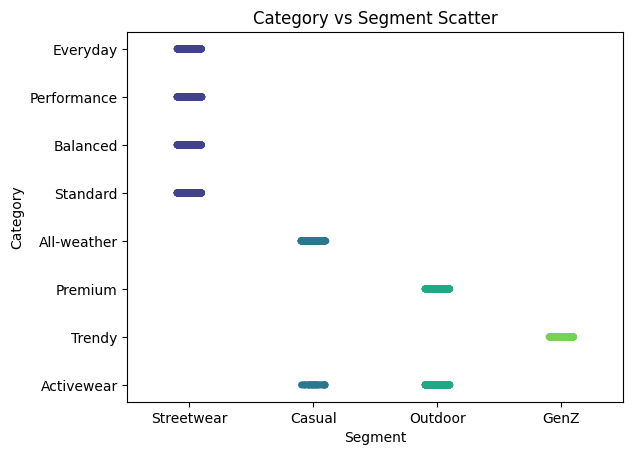

In [24]:
plot_category_segment(products)


PHÂN TÍCH MỐI QUAN HỆ GIỮA 'price' VÀ 'cogs'

[1] THỐNG KÊ MÔ TẢ:
   - price: mean = 4928.22, std = 4776.74, min = 9.06, max = 40950.00
   - cogs: mean = 3868.35, std = 3878.58, min = 5.18, max = 38902.50
   - Chênh lệch trung bình (price - cogs): 1059.87

[2] TƯƠNG QUAN:
   - Pearson: r = 0.967 (p-value = 0.00e+00) → có ý nghĩa thống kê
   - Spearman: ρ = 0.981 (p-value = 0.00e+00) → có ý nghĩa thống kê


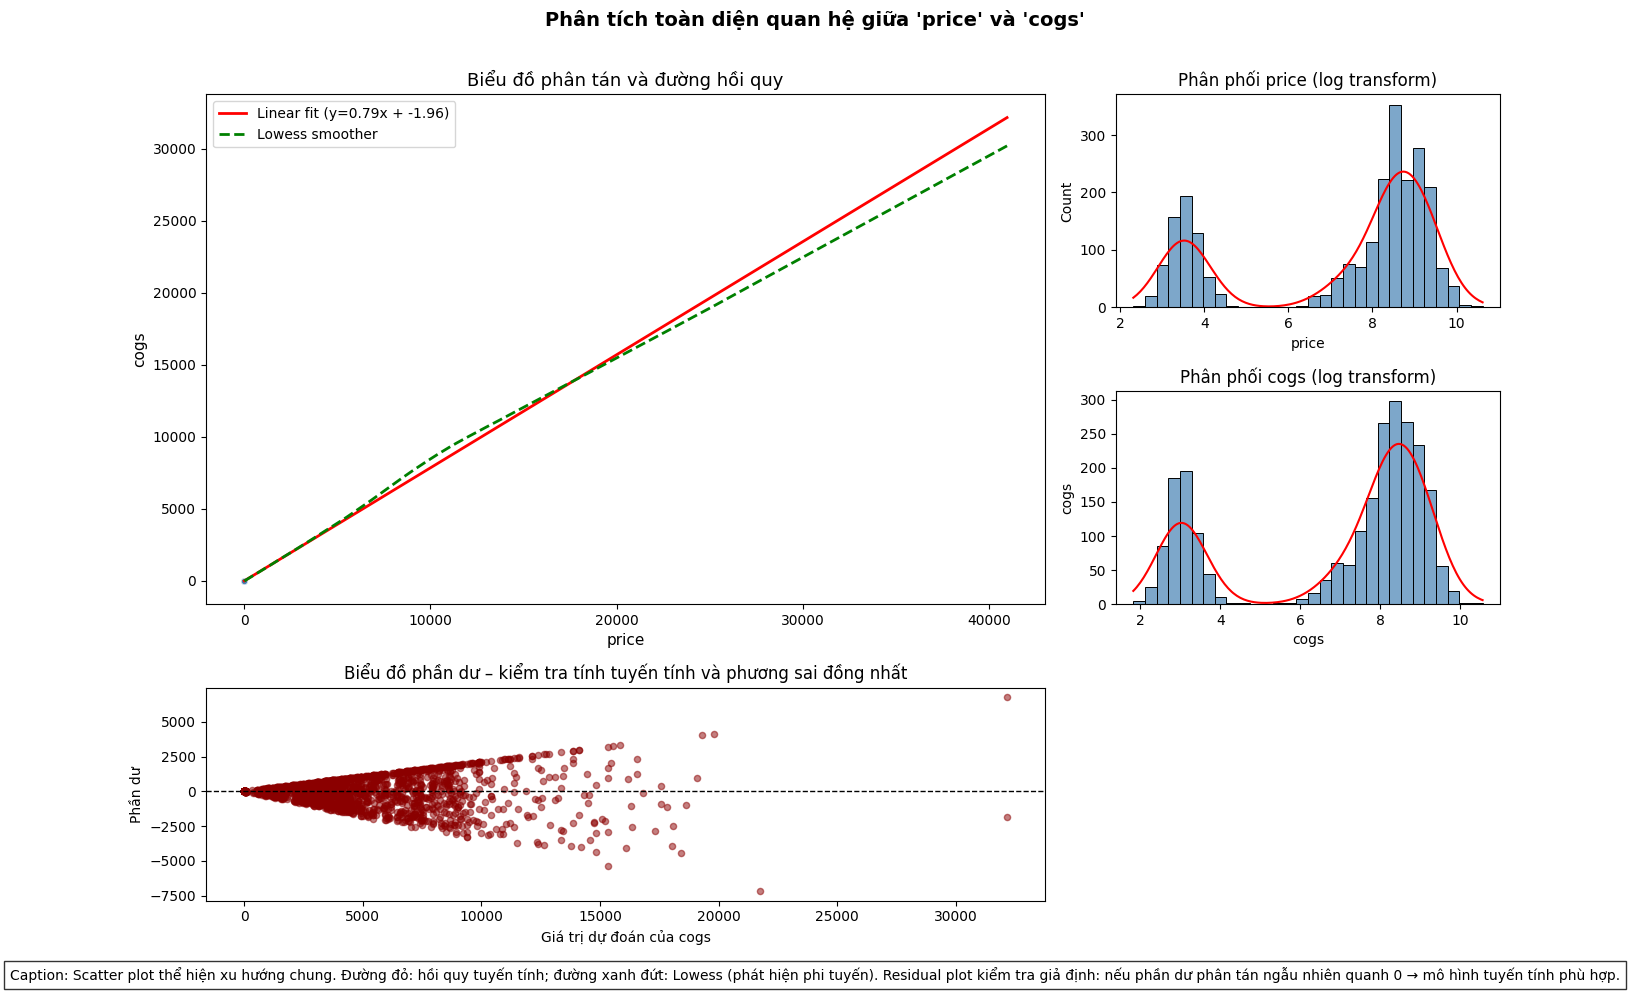


[3] KIỂM TRA PHƯƠNG SAI THAY ĐỔI (Breusch-Pagan):
   - LM statistic = 939.635, p-value = 2.38e-206
   - Kết luận: Có dấu hiệu phương sai thay đổi (homoscedasticity bị vi phạm)


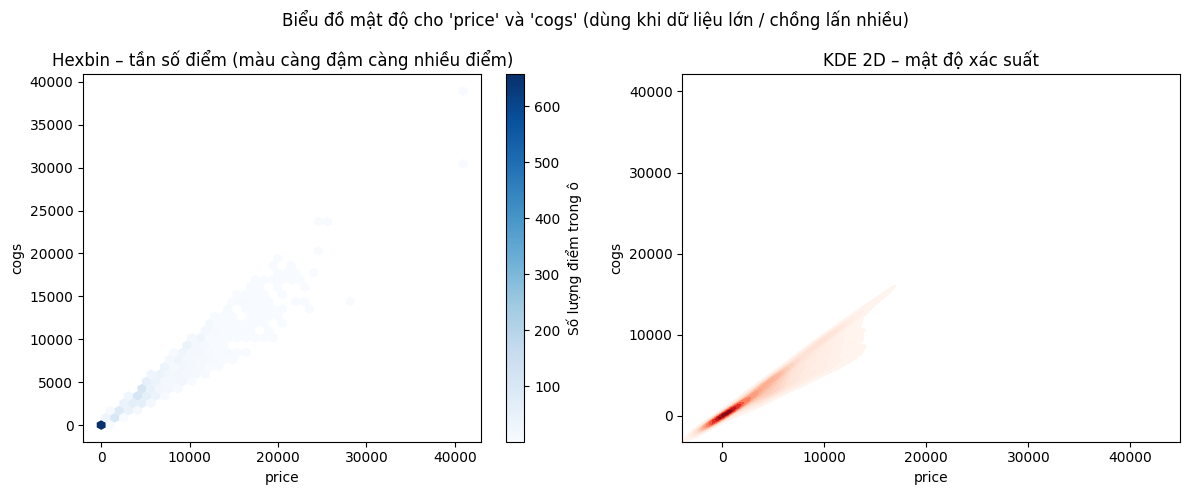

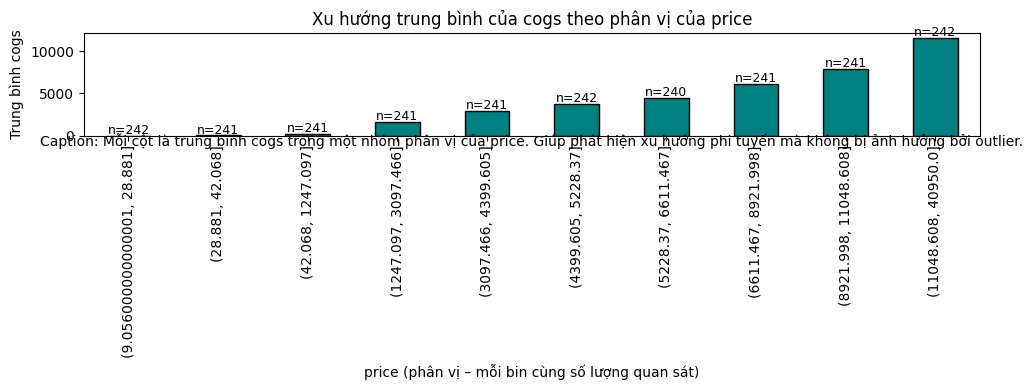


[4] NHẬN XÉT TỔNG HỢP:
   - Tương quan rất mạnh (|r| = 0.97)
   - Pearson và Spearman tương đồng → quan hệ gần tuyến tính hoặc đơn điệu.
   - Có hiện tượng phương sai thay đổi → cân nhắc sử dụng hồi quy vững (robust regression) hoặc biến đổi log.


In [25]:
explore_continuous_relationship(products, 'price', 'cogs')


HỒI QUY PHÂN VỊ CHO cogs THEO price

Phân vị 10%:
  price -> cogs: hệ số góc = 0.5685 (KTC 95%: [0.5655, 0.5715])
  Hệ số chặn = -0.3514

Phân vị 25%:
  price -> cogs: hệ số góc = 0.6606 (KTC 95%: [0.6572, 0.6641])
  Hệ số chặn = -2.9656

Phân vị 50%:
  price -> cogs: hệ số góc = 0.8018 (KTC 95%: [0.7985, 0.8050])
  Hệ số chặn = -6.5398

Phân vị 75%:
  price -> cogs: hệ số góc = 0.9505 (KTC 95%: [0.9479, 0.9530])
  Hệ số chặn = -8.4704

Phân vị 90%:
  price -> cogs: hệ số góc = 0.9500 (KTC 95%: [0.9487, 0.9513])
  Hệ số chặn = -0.0000


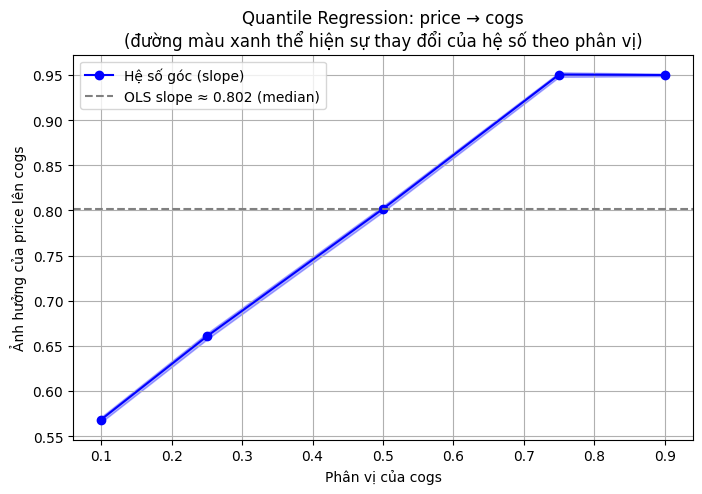

[{'quantile': 0.1,
  'slope': np.float64(0.5684975224571708),
  'intercept': np.float64(-0.35138653557159216),
  'slope_lower': np.float64(0.5655345477804826),
  'slope_upper': np.float64(0.5714604971338589)},
 {'quantile': 0.25,
  'slope': np.float64(0.6606425405805485),
  'intercept': np.float64(-2.9655747612123378),
  'slope_lower': np.float64(0.6571638951672221),
  'slope_upper': np.float64(0.6641211859938749)},
 {'quantile': 0.5,
  'slope': np.float64(0.801792236467102),
  'intercept': np.float64(-6.539798732512281),
  'slope_lower': np.float64(0.7985442616715897),
  'slope_upper': np.float64(0.8050402112626143)},
 {'quantile': 0.75,
  'slope': np.float64(0.9504711796499743),
  'intercept': np.float64(-8.470363575333582),
  'slope_lower': np.float64(0.947918137904795),
  'slope_upper': np.float64(0.9530242213951536)},
 {'quantile': 0.9,
  'slope': np.float64(0.9500000001684574),
  'intercept': np.float64(-1.8046412151306868e-06),
  'slope_lower': np.float64(0.9486628595029295),
  

In [32]:
quantile_regression_analysis(df=products, col_x='price', col_y='cogs')

In [26]:
anova_test(products)


ANOVA TEST: Price by Category
- F-statistic: 182.76
- p-value: 0.00000
Có sự khác biệt giá giữa các category


In [27]:
chi_square_test(products)


CHI-SQUARE TEST: Category vs Segment
- Chi2: 6774.23
- p-value: 0.00000
Có mối quan hệ giữa category và segment
